##**PROBLEM STATEMENT**##

The goal of this project is to create an interactive web application that predicts real estate prices using machine learning models. This app is designed to address the growing need for accurate property valuations. It will provide buyers, sellers, and real estate professionals with data-driven insights, empowering them to make informed decisions in a dynamic market.

##**SETUP PHASE**##


*   Installing Necessary Libraries
*   Importing Necessary Libraries
*   Reading the data






In [ ]:
#Installing Libraries

!pip install category_encoders

In [ ]:
##Importing Necessary Libraries##

!pip install category_encoders
import pandas as pd
import category_encoders as ce
import numpy as np
import sklearn
sklearn.set_config(transform_output="pandas")
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import joblib
from google.colab import drive
drive.mount('/content/drive')
filepath = '/content/drive/MyDrive/RealEstate_dataset.csv'




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#Reading the data using Pandas

estate = pd.read_csv(filepath)
estate

,Date,Year,Locality,Estimated Value,Sale Price,Property,Residential,num_bathrooms,num_rooms,carpet_area,property_tax_rate,Face
0,02/01/2009,2009,Waterbury,111440.0,185000,Single Family,Detached House,3,3,996.0,1.025953,South
1,02/01/2009,2009,NaN,73080.0,152000,Single Family,Detached House,3,1,935.0,1.025953,North
2,02/01/2009,2009,Waterbury,50540.0,105000,Single Family,Detached House,3,1,951.0,1.025953,East
3,02/01/2009,2009,Norwalk,571060.0,1000000,Single Family,Detached House,3,2,NaN,1.025953,South
4,02/01/2009,2009,Bridgeport,4775276.0,272900,Single Family,Detached House,3,1,971.0,1.025953,East
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,30/09/2022,2022,NaN,155550.0,215000,Three Family,Triplex,6,5,2114.0,1.003979,North
9996,30/09/2022,2022,Greenwich,NaN,2162500,Single Family,Detached House,3,3,933.0,1.003979,North
9997,30/09/2022,2022,West Hartford,124740.0,225635,Single Family,Detached House,3,1,922.0,1.003979,North
9998,30/09/2022,2022,NaN,1455230.0,2625000,Single Family,Detached House,3,2,977.0,1.003979,North


##**DATA CLEANING AND EDA**##




*   Checking Data Information
*   Checking Missing Data
*   Handling Missing Data
*   Checking for Duplicates
*   Checking For Outliers Using Boxplox
*   Handling Outlier Values
*   Encoding Categorical Variable














In [ ]:
#Checking Data information
estate.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               10000 non-null  object 
 1   Year               10000 non-null  int64  
 2   Locality           8745 non-null   object 
 3   Estimated Value    8771 non-null   float64
 4   Sale Price         10000 non-null  int64  
 5   Property           10000 non-null  object 
 6   Residential        10000 non-null  object 
 7   num_bathrooms      10000 non-null  int64  
 8   num_rooms          10000 non-null  int64  
 9   carpet_area        8718 non-null   float64
 10  property_tax_rate  10000 non-null  float64
 11  Face               10000 non-null  object 
dtypes: float64(3), int64(4), object(5)
memory usage: 937.6+ KB


In [ ]:
# Identifying Missing data

estate.isna().sum()

,0
Date,0
Year,0
Locality,1255
Estimated Value,1229
Sale Price,0
Property,0
Residential,0
num_bathrooms,0
num_rooms,0
carpet_area,1282


In [ ]:
estate["Property"].value_counts()

,count
Property,
Single Family,6797
?,1788
Two Family,851
Three Family,480
Four Family,84


In [ ]:
#Handling Missing Values

estate["Locality"].ffill(inplace =True)
estate["Estimated Value"].fillna(estate["Estimated Value"].mean(),inplace = True)
estate["carpet_area"].fillna(estate["carpet_area"].mean(), inplace = True)
estate["Property"].replace("?",np.nan,inplace=True)
estate["Property"].fillna(method='ffill', inplace=True)
estate["Estimated Value"].replace(0,estate["Estimated Value"].mean(),inplace = True)


In [ ]:
#Cheking for Duplicates

estate.duplicated().sum()

0

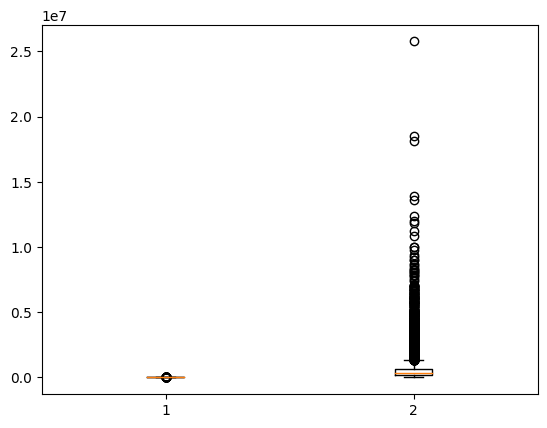

In [ ]:
#Checking For Outliers using Boxplot
plt.boxplot(estate[["num_rooms","Sale Price"]])
plt.show()

In [ ]:
for column in estate.select_dtypes("number").columns:

  # first step: get the 25th and 75th percentiles
  Q1 = estate[column].quantile(0.25)
  Q2 = estate[column].quantile(0.75)

  # second step: calculate inter-quartile range
  IQR = Q2 - Q1

  # get the lower and upper bounds using 25th and 75th percentiles, and inter-quartile range
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q2 + 1.5 * IQR

  # floor the outliers: replace outliers with lower & upper bounds
  estate[column] = np.where(estate[column] > upper_bound, upper_bound, estate[column])

  estate[column] = np.where(estate[column] < lower_bound, lower_bound, estate[column])



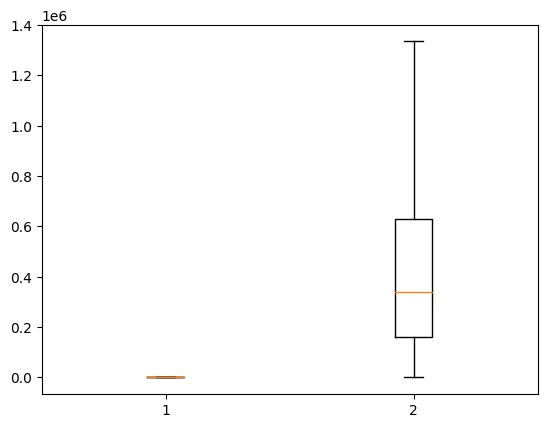

In [ ]:
#Boxplot after handling Outliers
plt.boxplot(estate[["num_rooms","Sale Price"]])
plt.show()

In [ ]:
estate.select_dtypes("object").nunique()

,0
Date,3089
Locality,7
Property,4
Residential,4
Face,4


In [ ]:
estate.select_dtypes("number").corr()

,Year,Estimated Value,Sale Price,num_bathrooms,num_rooms,carpet_area,property_tax_rate
Year,1.000000,-0.031455,0.017478,NaN,-0.022625,-0.004616,0.026657
Estimated Value,-0.031455,1.000000,0.864605,NaN,-0.153232,-0.201286,-0.013010
Sale Price,0.017478,0.864605,1.000000,NaN,-0.173136,-0.218576,-0.028090
num_bathrooms,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_rooms,-0.022625,-0.153232,-0.173136,NaN,1.000000,0.519662,-0.014881
carpet_area,-0.004616,-0.201286,-0.218576,NaN,0.519662,1.000000,-0.031512
property_tax_rate,0.026657,-0.013010,-0.028090,NaN,-0.014881,-0.031512,1.000000


<Axes: >

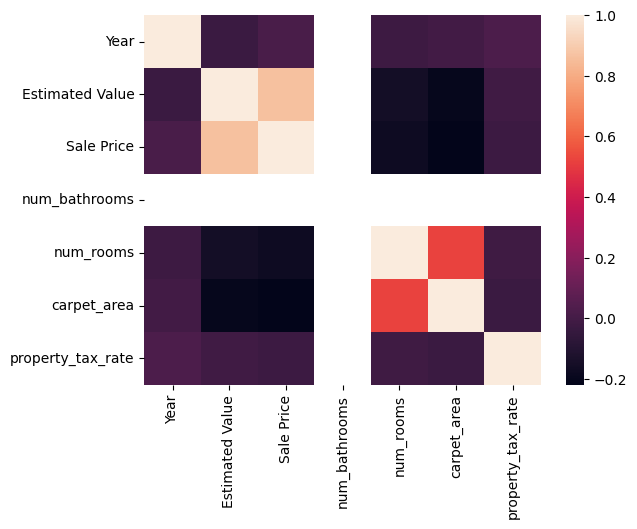

In [ ]:
sns.heatmap(estate.select_dtypes("number").corr())

In [ ]:
estate.drop(columns
            =["num_bathrooms","Year"],inplace = True)

In [ ]:
estate.drop(columns
            =["Estimated Value","property_tax_rate"],inplace = True)

In [ ]:
estate.drop(columns
            =["carpet_area"],inplace = True)

<Axes: >

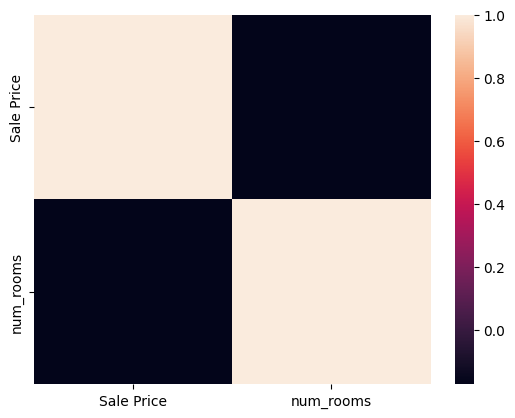

In [ ]:
sns.heatmap(estate.select_dtypes("number").corr())

In [ ]:
#Applying the Binary Encoding on the categorical column
#First we have to extract the categorical columns

category = estate[["Property","Residential","Face","Locality"]]
category

,Property,Residential,Face,Locality
0,Single Family,Detached House,South,Waterbury
1,Single Family,Detached House,North,Waterbury
2,Single Family,Detached House,East,Waterbury
3,Single Family,Detached House,South,Norwalk
4,Single Family,Detached House,East,Bridgeport
...,...,...,...,...
9995,Three Family,Triplex,North,Fairfield
9996,Single Family,Detached House,North,Greenwich
9997,Single Family,Detached House,North,West Hartford
9998,Single Family,Detached House,North,West Hartford


In [ ]:
#Applying the Binary encoding to transform the categorical data to Numerical

binary_encoder = ce.BinaryEncoder(cols=["Property","Residential","Face","Locality"])
binary_encoder.fit(category)
estate_encoded = binary_encoder.transform(category)
estate_encoded


,Property_0,Property_1,Property_2,Residential_0,Residential_1,Residential_2,Face_0,Face_1,Face_2,Locality_0,Locality_1,Locality_2
0,0,0,1,0,0,1,0,0,1,0,0,1
1,0,0,1,0,0,1,0,1,0,0,0,1
2,0,0,1,0,0,1,0,1,1,0,0,1
3,0,0,1,0,0,1,0,0,1,0,1,0
4,0,0,1,0,0,1,0,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,1,0,1,1,0,1,0,1,0,1
9996,0,0,1,0,0,1,0,1,0,1,0,0
9997,0,0,1,0,0,1,0,1,0,1,1,0
9998,0,0,1,0,0,1,0,1,0,1,1,0


In [ ]:
#Merging the Tranformed Categorical columns with the needed numerical column for the Regression Model

#First we pick the numerical columns we want to use

numerical = estate[["Sale Price","num_rooms"]]

#We merge using the concat

estate_new = pd.concat([estate_encoded,numerical],axis = 1)
estate_new


,Property_0,Property_1,Property_2,Residential_0,Residential_1,Residential_2,Face_0,Face_1,Face_2,Locality_0,Locality_1,Locality_2,Sale Price,num_rooms
0,0,0,1,0,0,1,0,0,1,0,0,1,185000.0,3.0
1,0,0,1,0,0,1,0,1,0,0,0,1,152000.0,1.0
2,0,0,1,0,0,1,0,1,1,0,0,1,105000.0,1.0
3,0,0,1,0,0,1,0,0,1,0,1,0,1000000.0,2.0
4,0,0,1,0,0,1,0,1,1,0,1,1,272900.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0,1,1,0,1,1,0,1,0,1,0,1,215000.0,5.0
9996,0,0,1,0,0,1,0,1,0,1,0,0,1335000.0,3.0
9997,0,0,1,0,0,1,0,1,0,1,1,0,225635.0,1.0
9998,0,0,1,0,0,1,0,1,0,1,1,0,1335000.0,2.0


In [ ]:
estate_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Property_0     10000 non-null  int64  
 1   Property_1     10000 non-null  int64  
 2   Property_2     10000 non-null  int64  
 3   Residential_0  10000 non-null  int64  
 4   Residential_1  10000 non-null  int64  
 5   Residential_2  10000 non-null  int64  
 6   Face_0         10000 non-null  int64  
 7   Face_1         10000 non-null  int64  
 8   Face_2         10000 non-null  int64  
 9   Locality_0     10000 non-null  int64  
 10  Locality_1     10000 non-null  int64  
 11  Locality_2     10000 non-null  int64  
 12  Sale Price     10000 non-null  float64
 13  num_rooms      10000 non-null  float64
dtypes: float64(2), int64(12)
memory usage: 1.1 MB


In [ ]:
estate["num_rooms"].value_counts()

,count
num_rooms,
3.0,3123
2.0,3061
1.0,2777
4.0,536
6.0,309
5.0,194


In [ ]:
#Checking For null valuesin our New Table
estate_new.isna().sum()

,0
Property_0,0
Property_1,0
Property_2,0
Residential_0,0
Residential_1,0
Residential_2,0
Face_0,0
Face_1,0
Face_2,0
Locality_0,0


In [ ]:
#DEFINING THE FEATURE AND THE TARGET VARIABLE

#Feature Variable

X = estate_new.drop(['Sale Price'] ,axis=1)

#Target Variable
y = estate_new["Sale Price"]


In [ ]:
#Checking if they are of the same rows and columns

print(X.shape)
print(y.shape)

(10000, 13)
(10000,)


In [ ]:
#SPLITTING THE DATA INTO TRAINING AND TESTING(80% TRAINING)

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)


In [ ]:
# creating the baseline model

# first we calculate the mean
y_mean = y_train.mean()

y_mean

465946.81225

In [ ]:
# create the baseline (mean) values

y_pred_baseline = [y_mean] * len(y_train)

y_pred_baseline[:5]


[465946.81225, 465946.81225, 465946.81225, 465946.81225, 465946.81225]

In [ ]:
# measure performance of the dumb model
# we will be using the mean absolute error (MAE)

mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print(f"Mean Sale Price value price: {round(y_mean, 2)}")
print(f"Mean absolute error for Baseline: {round(mae_baseline, 2)}")

Mean Sale Price value price: 465946.81
Mean absolute error for Baseline: 316651.15


**CREATING THE MAIN MODEL**

In [ ]:
#Model used
model = RandomForestRegressor(random_state = 42)
model


RandomForestRegressor(random_state=42)

In [ ]:
#Training our data with the Feature and Target Variable

model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [ ]:
#Predicting on the test set with the trained data

y_pred_train = model.predict(X_train)

y_pred_train

array([ 619029.04068626,  633671.97960805,  151998.29777842, ...,
        353174.57979072, 1127024.61549852,  154427.67237475])

In [ ]:
#Evaluating the Model Performance

# measure performance of the main model with training data
# we will be using the mean absolute error (MAE)

mean_training = mean_absolute_error(y_train, y_pred_train)

print(f"Mean absolute error for main Model with training data: {round(mean_training, 2)}")

Mean absolute error for main Model with training data: 184895.57


In [ ]:
#Predicting on the test data

y_pred_test = model.predict(X_test)

y_pred_test

array([ 518384.99910202,  612883.24508356,  306468.39320508, ...,
       1097432.59040152,  237985.82089721,  650344.66447887])

In [ ]:
mean_test = mean_absolute_error(y_test, y_pred_test)

print(f"Mean absolute error for main Model with testing data: {round(mean_test, 2)}")

Mean absolute error for main Model with testing data: 197768.76


**MODEL EVALUATION**

**CHECKING THE DIFFERENCES IN THE MEAN ABSOLUTE ERROR**

*  MAE for Training Model (184894.29) < MAE for Baseline model (316651.15)
*  MAE for Training Model (184894.29) < MAE for Testing Model (197717.51)


This shows that our model is performing well and generalizes well for unseen data

```
# This is formatted as code
```







**VISUALIZATION TO CHECK HOW WELL OUR MODEL GENERALIZES**


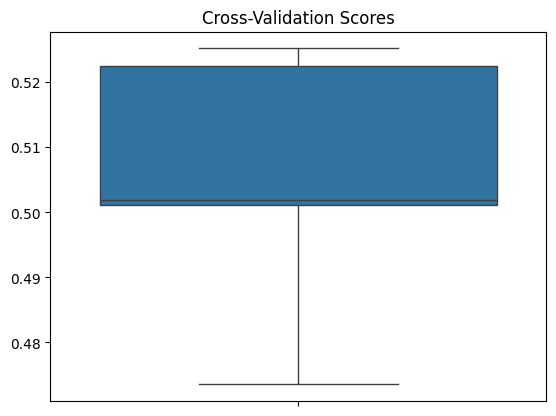

In [ ]:
#CROSS VALIDATION BOXPLOT

scores = cross_val_score(model, X, y, cv=5)
sns.boxplot(scores)
plt.title('Cross-Validation Scores')
plt.show()

**REPORTING**

Our cross-validation boxplot shows no outliers, indicating that the model performs consistently when cross-validation is applied. This process involves splitting the data into five parts, with four parts used for training and one for testing, repeated five times. The absence of outliers suggests that the model delivers stable performance across different splits of the data, meaning it generalizes well to unseen data.

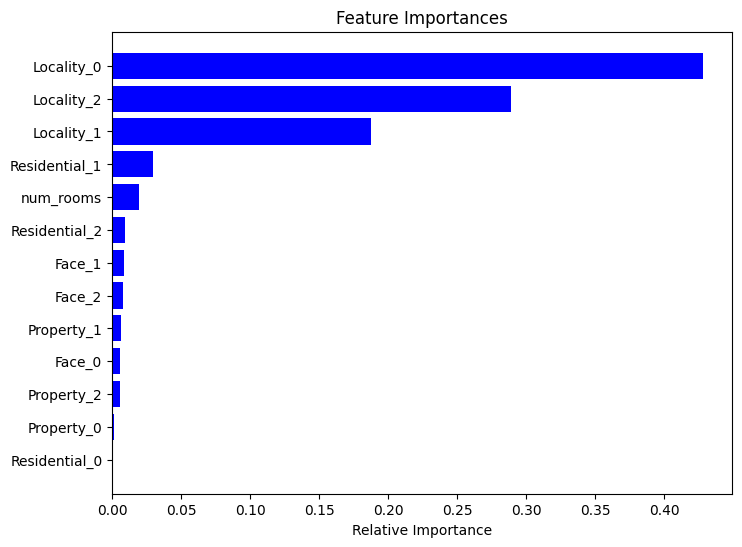

In [ ]:
#Checking For Feature Importance

importances = model.feature_importances_
features = X.columns
indices = np.argsort(importances)

plt.figure(figsize=(8,6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

**SAVING OUR MODEL AND ENCODER USING JOBLIB**

In [ ]:
#Saving the model
joblib.dump(model,"estate")

['estate']

In [ ]:
joblib.dump(binary_encoder,"Binary Encoder")

['Binary Encoder']

**Streamlit Code**

The code below configures streamlit with inputs for entering feature values, and using the model to predict a corresponding target value.

The code is then saved in an app.py file

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib
import numpy as np

#Loading the model into a variable
model = joblib.load("estate")

#Loading the Encoder into a variable
encoder = joblib.load("Binary Encoder")

# Defining function to predict prices
def predict_price(features):
    prediction = model.predict([features])
    return prediction[0]

# Streamlit app layout
st.title("REAL ESTATE PRICE PREDICTION APP")
st.sidebar.title("DATA SCIENCE CAPSTONE PROJECT")
st.sidebar.subheader("GROUP C")


st.header("Select Property Characteristics:")

# Input fields for the categorical variables
property_type = st.selectbox("Property",["Single Family","Two Family","Three Family","Four Family"])
residential_type = st.selectbox("Residential",["Detached House","Duplex","Triplex","Fourplex"])
face = st.selectbox("Face", ["North", "East", "South","West"])
locality = st.selectbox("Locality", ["Bridgeport", "Waterbury", "Fairfield", "West Hartford", "Greenwich", "Stamford", "Norwalk"])

# Numeric input fields for number of rooms and bathrooms
num_rooms = st.number_input("Number of Rooms", min_value=1, max_value=6, value=3, step=1)

# Create a DataFrame from user input
input_data = pd.DataFrame({
    'Property': [property_type],
    'Residential': [residential_type],
    'Face': [face],
    'Locality': [locality],
    'Number of Rooms': [num_rooms],

})

# Encode the input data using the loaded encoder for categorical variables only
categorical_data = input_data[['Property','Residential',"Face","Locality"]]
encoded_input = encoder.transform(categorical_data)

# Combine the encoded categorical data with the numeric inputs
numeric_data = input_data[['Number of Rooms']]
final_input = pd.concat([encoded_input, numeric_data], axis=1)


# Predict the price when the user clicks the button
if st.button("Predict Price"):
    input_features = final_input.iloc[0].values
    price = predict_price(input_features)
    st.write(f"The predicted price for the property is: ${price:,.2f}")

# Feedback Section
st.header("We value your feedback!")
feedback = st.text_area("Please leave your feedback or suggestions here:")
if st.button("Submit Feedback"):
    if feedback:
        st.write("Thank you for your feedback!")
    else:
        st.write("Feedback cannot be empty. Please enter your thoughts.")



Writing app.py


**requirements.txt file**

Deploy the Streamlit app, a requirements.txt file has to be included in the github repository.

Run the code below to create the requirements.txt file.

In [ ]:
%%writefile requirements.txt


streamlit
scikit-learn
numpy
joblib
category_encoders

Writing requirements.txt


In [ ]:
from google.colab import files
files.download("estate")
files.download("Binary Encoder")
files.download("app.py")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>